<a href="https://colab.research.google.com/github/vananhnt2801/Carbon-Price-Forecasting/blob/main/%5B19_08_26%5D_CTr2L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving shanghai.csv to shanghai.csv
Saving guangdong.csv to guangdong.csv


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: []


In [3]:
def load_and_clean(path):
    d = pd.read_csv(path)
    d.columns = [c.strip() for c in d.columns]
    rename_map = {c: 'ProductionCoal' for c in d.columns if c.lower() == 'production(coal)'}
    d = d.rename(columns=rename_map)
    d['TradingDate'] = pd.to_datetime(d['TradingDate'], format='%Y/%m/%d')
    d = d.sort_values('TradingDate').reset_index(drop=True)
    return d

guangdong = load_and_clean('guangdong.csv')   # source domain
shanghai  = load_and_clean('shanghai.csv')    # target domain

print("Guangdong:", guangdong.shape)
print("Shanghai:", shanghai.shape)

Guangdong: (1477, 12)
Shanghai: (491, 12)


In [4]:
FEAT_COLS = ['LowPrice', 'Volume', 'n', 'PMI', 'Margin Trading', 'ProductionCoal', 'USD', 'AQI', 'garch']
TARGET_COL = 'vola'
L = 5

def make_sequences(df, feat_cols, target_col, L=5):
    all_cols = feat_cols + [target_col]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(df[all_cols].values)
    X, y = [], []
    for i in range(L, len(scaled)):
        X.append(scaled[i-L:i, 0:-1])
        y.append(scaled[i, -1])
    return np.array(X), np.array(y), scaler

def inverse_target(pred_scaled, scaler, n_features):
    dummy = np.zeros((len(pred_scaled), n_features + 1))
    dummy[:, -1] = pred_scaled
    return scaler.inverse_transform(dummy)[:, -1]

X_gd, y_gd, scaler_gd = make_sequences(guangdong, FEAT_COLS, TARGET_COL, L=L)
X_sh, y_sh, scaler_sh = make_sequences(shanghai, FEAT_COLS, TARGET_COL, L=L)
print("Guangdong sequences:", X_gd.shape, "| Shanghai sequences:", X_sh.shape)

Guangdong sequences: (1472, 5, 9) | Shanghai sequences: (486, 5, 9)


In [5]:
def split_80_5_15(X, y):
    n = len(X)
    train_end = int(n * 0.80)
    val_end   = int(n * 0.85)
    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:])

Xgd_tr, ygd_tr, Xgd_va, ygd_va, Xgd_te, ygd_te = split_80_5_15(X_gd, y_gd)
Xsh_tr, ysh_tr, Xsh_va, ysh_va, Xsh_te, ysh_te = split_80_5_15(X_sh, y_sh)

print(f"Guangdong -> train {len(Xgd_tr)} val {len(Xgd_va)} test {len(Xgd_te)}")
print(f"Shanghai  -> train {len(Xsh_tr)} val {len(Xsh_va)} test {len(Xsh_te)}")

Guangdong -> train 1177 val 74 test 221
Shanghai  -> train 388 val 25 test 73


In [6]:
def build_rnn(n_features, cell='GRU', units1=5, units2=5):
    Cell = layers.GRU if cell == 'GRU' else layers.LSTM
    inputs = layers.Input(shape=(None, n_features))
    x = Cell(units1, return_sequences=True, name='G1')(inputs)
    x = Cell(units2, name='G2')(x)
    out = layers.Dense(1, name='D1')(x)     # không ép activation — target đã scale 0-1
    m = models.Model(inputs, out)
    m.compile(optimizer='adam', loss='mse')
    return m

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)
    return rmse, mae, medae

In [7]:
results = {}
n_feat = len(FEAT_COLS)
early_stop = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)

for cell_name in ['LSTM', 'GRU']:
    m = build_rnn(n_feat, cell=cell_name)
    m.fit(Xgd_tr, ygd_tr, validation_data=(Xgd_va, ygd_va),
          epochs=150, batch_size=32, verbose=0, callbacks=[early_stop])
    pred_scaled = m.predict(Xgd_te, verbose=0).flatten()

    y_true_real = inverse_target(ygd_te, scaler_gd, n_feat)
    pred_real   = inverse_target(pred_scaled, scaler_gd, n_feat)
    results[cell_name] = evaluate(y_true_real, pred_real)

    if cell_name == 'GRU':
        baseline_gru_model = m   # giữ lại dùng cho CTr2L

for name, (rmse, mae, medae) in results.items():
    print(f"{name:10s} RMSE={rmse:.5f} MAE={mae:.5f} MedAE={medae:.5f}")

LSTM       RMSE=0.01414 MAE=0.01045 MedAE=0.00848
GRU        RMSE=0.04051 MAE=0.03583 MedAE=0.03158


In [8]:
g1_layer = baseline_gru_model.get_layer('G1')
g1_layer.trainable = False

inputs2 = layers.Input(shape=(None, n_feat))
g1_out = g1_layer(inputs2)
g2_new = layers.GRU(10, name='G2_new')(g1_out)
out_new = layers.Dense(1, name='D1_new')(g2_new)

ctr2l_model = models.Model(inputs2, out_new)
ctr2l_model.compile(optimizer='adam', loss='mse')

es_ctr2l = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
ctr2l_model.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),
                epochs=150, batch_size=32, verbose=0, callbacks=[es_ctr2l])

pred_ctr2l_scaled = ctr2l_model.predict(Xsh_te, verbose=0).flatten()
ytrue_sh_real = inverse_target(ysh_te, scaler_sh, n_feat)
pred_ctr2l_real = inverse_target(pred_ctr2l_scaled, scaler_sh, n_feat)

rmse_c, mae_c, medae_c = evaluate(ytrue_sh_real, pred_ctr2l_real)
print(f"CTr2L RMSE={rmse_c:.5f} MAE={mae_c:.5f} MedAE={medae_c:.5f}")

CTr2L RMSE=0.02043 MAE=0.01726 MedAE=0.01734


In [9]:
baseline_sh_only = build_rnn(n_feat, cell='GRU')
es_baseline = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
baseline_sh_only.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),
                      epochs=150, batch_size=32, verbose=0, callbacks=[es_baseline])

pred_baseline_scaled = baseline_sh_only.predict(Xsh_te, verbose=0).flatten()
pred_baseline_real = inverse_target(pred_baseline_scaled, scaler_sh, n_feat)
rmse_b, mae_b, medae_b = evaluate(ytrue_sh_real, pred_baseline_real)

print(f"Baseline (no transfer) RMSE={rmse_b:.5f} MAE={mae_b:.5f} MedAE={medae_b:.5f}")
print(f"CTr2L                  RMSE={rmse_c:.5f} MAE={mae_c:.5f} MedAE={medae_c:.5f}")

Baseline (no transfer) RMSE=0.02387 MAE=0.02115 MedAE=0.02322
CTr2L                  RMSE=0.02043 MAE=0.01726 MedAE=0.01734


In [11]:
np.random.seed(42)
noise_rmses = []

for trial in range(100):
    X_noise = np.random.randn(*Xgd_tr.shape)
    y_noise = np.random.rand(*ygd_tr.shape)   # target giả cũng trong [0,1] vì đã MinMax

    noise_model = build_rnn(n_feat, cell='GRU')
    noise_model.fit(X_noise, y_noise, epochs=50, batch_size=32, verbose=0)

    g1_noise = noise_model.get_layer('G1')
    g1_noise.trainable = False
    inputs3 = layers.Input(shape=(None, n_feat))
    g1n_out = g1_noise(inputs3)
    g2n_new = layers.GRU(100, name=f'G2_noise_{trial}')(g1n_out)
    out3 = layers.Dense(1, name=f'D1_noise_{trial}')(g2n_new)
    noise_ctr2l = models.Model(inputs3, out3)
    noise_ctr2l.compile(optimizer='adam', loss='mse')

    es_noise = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
    noise_ctr2l.fit(Xsh_tr, ysh_tr, validation_data=(Xsh_va, ysh_va),
                     epochs=150, batch_size=32, verbose=0, callbacks=[es_noise])

    pred_noise_scaled = noise_ctr2l.predict(Xsh_te, verbose=0).flatten()
    pred_noise_real = inverse_target(pred_noise_scaled, scaler_sh, n_feat)
    rmse_n = np.sqrt(mean_squared_error(ytrue_sh_real, pred_noise_real))
    noise_rmses.append(rmse_n)
    print(f"Trial {trial+1}/100 - Noise CTr2L RMSE = {rmse_n:.5f}")

print(f"\n[Noise CTr2L] median RMSE = {np.median(noise_rmses):.5f}")
print(f"[CTr2L thật]  RMSE = {rmse_c:.5f}")

Trial 1/100 - Noise CTr2L RMSE = 0.03394
Trial 2/100 - Noise CTr2L RMSE = 0.02034
Trial 3/100 - Noise CTr2L RMSE = 0.02226
Trial 4/100 - Noise CTr2L RMSE = 0.04192
Trial 5/100 - Noise CTr2L RMSE = 0.03962
Trial 6/100 - Noise CTr2L RMSE = 0.02128
Trial 7/100 - Noise CTr2L RMSE = 0.02035
Trial 8/100 - Noise CTr2L RMSE = 0.01918
Trial 9/100 - Noise CTr2L RMSE = 0.02113
Trial 10/100 - Noise CTr2L RMSE = 0.02683
Trial 11/100 - Noise CTr2L RMSE = 0.02638
Trial 12/100 - Noise CTr2L RMSE = 0.01695
Trial 13/100 - Noise CTr2L RMSE = 0.02189
Trial 14/100 - Noise CTr2L RMSE = 0.01609
Trial 15/100 - Noise CTr2L RMSE = 0.02075
Trial 16/100 - Noise CTr2L RMSE = 0.01454
Trial 17/100 - Noise CTr2L RMSE = 0.03301
Trial 18/100 - Noise CTr2L RMSE = 0.01777
Trial 19/100 - Noise CTr2L RMSE = 0.02469
Trial 20/100 - Noise CTr2L RMSE = 0.07704
Trial 21/100 - Noise CTr2L RMSE = 0.02057
Trial 22/100 - Noise CTr2L RMSE = 0.02139
Trial 23/100 - Noise CTr2L RMSE = 0.02796
Trial 24/100 - Noise CTr2L RMSE = 0.02167
T

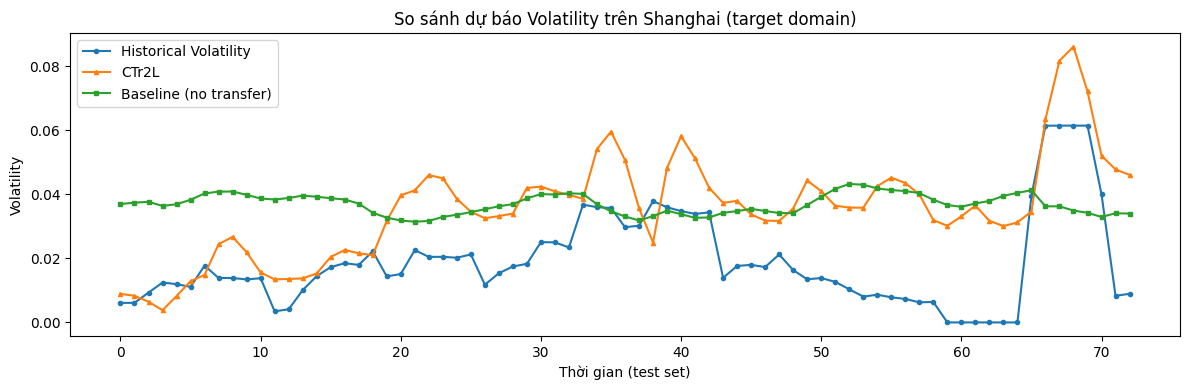

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ytrue_sh_real, label='Historical Volatility', marker='o', markersize=3)
plt.plot(pred_ctr2l_real, label='CTr2L', marker='^', markersize=3)
plt.plot(pred_baseline_real, label='Baseline (no transfer)', marker='s', markersize=3)
plt.legend(); plt.title('So sánh dự báo Volatility trên Shanghai (target domain)')
plt.xlabel('Thời gian (test set)'); plt.ylabel('Volatility')
plt.tight_layout(); plt.show()

In [13]:
get_ipython().system('pip install -q dtaidistance')
from dtaidistance import dtw
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

source_series = guangdong['vola'].values.astype(np.double)
target_series = shanghai['vola'].values.astype(np.double)
dtw_dist = dtw.distance(source_series, target_series)

min_len = min(len(guangdong), len(shanghai))
X_lasso = guangdong[FEAT_COLS].values[:min_len]
y_lasso = shanghai['vola'].values[:min_len]

lasso = Lasso(alpha=0.001, max_iter=5000)
lasso.fit(X_lasso, y_lasso)
y_lasso_pred = lasso.predict(X_lasso)
r2_lasso = max(r2_score(y_lasso, y_lasso_pred), 1e-6)

v_factor = dtw_dist / r2_lasso
print(f"DTW(Guangdong, Shanghai) = {dtw_dist:.4f}")
print(f"R2_Lasso = {r2_lasso:.4f}")
print(f"Transferability factor v = {v_factor:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 40.3 MB/s eta 0:00:00
DTW(Guangdong, Shanghai) = 0.4608
R2_Lasso = 0.2333
Transferability factor v = 1.9757
